In [46]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [47]:
data = tf.keras.datasets.fashion_mnist

In [48]:
(training_images, training_labels), (test_images, test_labels) = data.load_data()

I want to see what one of these training images look like.

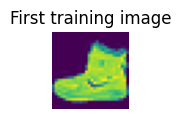

In [49]:
# First image
plt.figure(figsize=(1, 1))
plt.title("First training image")
plt.axis("off")
plt.imshow(training_images[0])
plt.show()

In [50]:
training_labels[0]

9

In [51]:
# Normalize the data
training_images = training_images / 255.0
test_images = test_images / 255.0

In [52]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation=tf.nn.relu),
        tf.keras.layers.Dense(10, activation=tf.nn.softmax),
    ]
)
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [53]:
class StopAt95(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get("accuracy") > 0.95:
            print("\nReached 95% accuracy so cancelling training!")
            self.model.stop_training = True


model.fit(training_images, training_labels, epochs=5, callbacks=[StopAt95()])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8097 - loss: 0.5534
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8408 - loss: 0.4624
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8451 - loss: 0.4482
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8462 - loss: 0.4453
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8471 - loss: 0.4440


In [54]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8140 - loss: 0.5257


[0.5257188677787781, 0.8140000104904175]

In [55]:
classifications = model.predict(test_images)
print(classifications[0])
print(test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step
[2.5955418e-07 9.1041485e-10 8.3654663e-07 4.9595972e-08 2.7711312e-07
 7.1964795e-03 2.5900194e-06 9.1084704e-02 1.7602211e-03 8.9995468e-01]
9
